In [1]:
import pandas as pd
import glob
import os
import scanpy as sc

In [2]:
from IPython.display import HTML, display
from cellphonedb.utils import db_releases_utils

display(HTML(db_releases_utils.get_remote_database_versions_html()['db_releases_html_table']))

In [3]:
sc.settings.figdir = "fig5"


In [4]:
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(20,20))


In [5]:
os.getcwd()

'/nfs/users/nfs_l/ls34/CCC_Analyses'

In [6]:
cpdb_version = 'v5.0.0'

# -- Path where the input files to generate the database are located
cpdb_target_dir = os.path.join('/nfs/team298/ls34/wound/cellphonedb/', cpdb_version)

In [7]:
from cellphonedb.utils import db_utils

db_utils.download_database(cpdb_target_dir, cpdb_version)

Downloaded cellphonedb.zip into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded complex_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded gene_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded interaction_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded protein_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded uniprot_synonyms.tsv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0/sources
Downloaded transcription_factor_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0/sources


In [8]:
cpdb_input_dir = '/nfs/team298/ls34/wound/cellphonedb/v5.0.0/'


In [9]:
from cellphonedb.utils import db_utils

# -- Creates new database
db_utils.create_db(cpdb_input_dir)


Created /nfs/team298/ls34/wound/cellphonedb/v5.0.0/cellphonedb_01_28_2026_221908.zip successfully


In [10]:
# %%bash

# mv /nfs/team298/ls34/cellphonedb/v5.0.0/cellphonedb_09_28_2024_123936.zip /nfs/team298/ls34/cellphonedb/v5.0.0/cellphonedb.zip

In [11]:
pd.set_option('display.max_columns', 100)

In [12]:
os.listdir(cpdb_target_dir)

['complex_input.csv',
 'cellphonedb_04_24_2025_144353.zip',
 'cellphonedb_07_13_2025_093414.zip',
 'cellphonedb_04_18_2025_084606.zip',
 'cellphonedb_07_12_2025_192405.zip',
 'cellphonedb_01_07_2026_161808.zip',
 'cellphonedb_07_13_2025_093659.zip',
 'cellphonedb_07_12_2025_164300.zip',
 'results',
 'gene_input.csv',
 'cellphonedb_07_12_2025_165925.zip',
 'cellphonedb_04_18_2025_085909.zip',
 'cellphonedb_04_20_2025_184622.zip',
 'cellphonedb.zip',
 'cellphonedb_02_11_2025_113059.zip',
 'cellphonedb_04_22_2025_143422.zip',
 'cellphonedb_07_12_2025_165926.zip',
 'sources',
 'interaction_input.csv',
 'cellphonedb_01_07_2026_170109.zip',
 'cellphonedb_07_13_2025_132659.zip',
 'cellphonedb_09_24_2025_092100.zip',
 'cellphonedb_02_11_2025_120244.zip',
 'cellphonedb_10_05_2025_110658.zip',
 'cellphonedb_07_12_2025_163222.zip',
 'cellphonedb_04_24_2025_100903.zip',
 'cellphonedb_04_24_2025_151255.zip',
 'cellphonedb_07_12_2025_192132.zip',
 'cellphonedb_10_03_2025_164440.zip',
 'cellphonedb_1

In [13]:
cpdb_file_path = os.path.join(cpdb_target_dir, 'cellphonedb.zip')
cpdb_file_path





'/nfs/team298/ls34/wound/cellphonedb/v5.0.0/cellphonedb.zip'

In [14]:
meta_file_path = '/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_MINTFLOWPLASMA.tsv'



In [15]:
out_path = '/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore'


In [16]:
metadata = pd.read_csv(meta_file_path, sep = '\t')
metadata.head(3)

,barcode_sample,cell_type
0,aaighcfa-1_output-XETG00155__0032945__AX34-SKI...,Plasma cell
1,adbcmaha-1_output-XETG00155__0032945__AX34-SKI...,cDC1
2,aemhlcpf-1_output-XETG00155__0032945__AX34-SKI...,KC1


In [17]:
metadata.cell_type.value_counts()

cell_type
Plasma cell                       5358
F7: Myofibroblast                  145
Pericyte1                           42
KC3                                 40
F6: Inflammatory myofibroblast      40
Tc                                  39
VE3_Ven                             33
KC1                                 33
pDC                                 28
F2/3: Perivascular                  27
Bcell                               22
F5: NGFR+                           22
F3: FRC-like                        12
F8: Fascia-like myofibroblast       12
Mac2                                12
cDC1                                11
Name: count, dtype: int64

In [18]:
import anndata
counts_file_path = '/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_MINTFLOWPLASMA.h5ad'
adata = anndata.read_h5ad(counts_file_path)
adata.shape

(5876, 1213)

In [19]:
list(adata.obs.index).sort() == list(metadata['barcode_sample']).sort()


True

In [20]:
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method

cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
    #active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
    #microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                       # optional: whether to score interactions or not. 
    iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
    threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
    threads = 5,                                     # number of threads to use in the analysis.
    debug_seed = 42,                                 # debug randome seed. To disable >=0.
    result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
    pvalue = 0.05,                                   # P-value threshold to employ for significance.
    subsampling = False,                             # To enable subsampling the data (geometri sketching).
    subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
    subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
    subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
    separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
    output_path = out_path,                          # Path to save results.
    output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
    )

Reading user files...
The following user files were loaded successfully:
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_MINTFLOWPLASMA.h5ad
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_MINTFLOWPLASMA.tsv
[ ][CORE][28/01/26-22:19:10][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:5 Precision:3
[ ][CORE][28/01/26-22:19:10][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][28/01/26-22:19:12][INFO] Running Real Analysis
[ ][CORE][28/01/26-22:19:12][INFO] Running Statistical Analysis


100%|██████████| 1000/1000 [00:24<00:00, 40.10it/s]

[ ][CORE][28/01/26-22:19:37][INFO] Building Pvalues result


[ ][CORE][28/01/26-22:19:37][INFO] Building results
[ ][CORE][28/01/26-22:19:37][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 16/16 [00:00<00:00, 231.19it/s]

[ ][CORE][28/01/26-22:19:37][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 16/16 [00:00<00:00, 595.64it/s]


[ ][CORE][28/01/26-22:19:37][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 256/256 [00:02<00:00, 110.57it/s]


Saved deconvoluted to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_01_28_2026_221940.txt
Saved deconvoluted_percents to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_percents_01_28_2026_221940.txt
Saved means to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_01_28_2026_221940.txt
Saved pvalues to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_01_28_2026_221940.txt
Saved significant_means to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_significant_means_01_28_2026_221940.txt
Saved interaction_scores to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_01_28_2026_221940.txt


In [21]:
# KEEP_LIST = [#'Melanocyte',
#  #'KC3',
#  #'Sweat gland',
#  'Pericyte1_CCL19+_signalling',
#  'VE3_SELPhi',
#  'LE',
#  #'Sweat gland channel inner',
#  'VE1_ADAMTS6hi',
#  'F3: CCL19+',
#  'cDC1',
#  'Pericyte2_CASQ2_Muscle',
#  #'Sweat gland channel outer',
#  'nmSchwann',
#  'Mac2',
#  'F2/3: Bridge',
#  'F1: Superficial',
#  'LC',
#  'F2: Universal',
#  'F5: NGFR+',
#  'cDC2: IL1B+',
# # 'F4: TNN+COCH+',
#  'F1: Superficial regenerative',
#  #'Cartilage',
#  'cDC2: MMP12+',
#  #'KC_HF/SC: LGR6+ACTA2+',
#  'F5: RAMP1+',
#  'MigDC',
# # 'F4: DS_DPEP1+',
#  #'mSchwann',
#  #'KC1',
#  'ILC1_3',
#  'Plasma cell',
#  'MoDC',
#  'F6: Myofibroblast inflammatory',
#  #'pDC',
#  'Tc_IFNGhi',
#  #'Smooth muscle',
#  #'Bcell',
#  'Tc_IL13',
#  #'F4: DP_HHIP+',
#  'Treg',
#  'ILC2_inflammatory',
#  'Th',
#  'Tc',
# # 'KC_Sebocyte_basal',
# # 'KC_Sebocyte_inner',
#  'VE2',
#  #'Mono',
#  #'MacTREM2_CX3CR1+',
#  'NK',
#  'ILC1_NK',
#  'Tc_gamma_delta',
#  'Tr1',
#  'Mast cell',
#  'Tnaive/Tcm',
#  #'KC4',
#  #'KC2/3_cycling',
#  #'KC2',
#  #'KCinflamm_basal',
#  #'KCinflamm_int',
#  #'KC5',
#  'ILC2',
#  #'KC_HF: ORS/CL',
#  #'KC_HF: Basal_LGR5+',
#  #'F_Fascia',
#  #'Merkel cell',
#  #'KC_HF: Basal_NPNT+',
#  #'Mono CD16+',
#  #'KC_HF: IRS+HS',
#  'Mac1',
#  #'KCinflamm_late',
#  #'KCinflamm_cycling',
#  'Tc_IL17',
#  #'Satellite muscle',
#  #'Adipocyte',
#  #'Neutrophil',
#  #'Skeletal muscle'
# ]
# KEEP_LIST

In [22]:
1

1

In [23]:
# missing_in_counts = meta.index.difference(counts.columns)
# print("meta-only cells:", len(missing_in_counts))

# # 2️⃣ barcodes present in counts but not in meta
# missing_in_meta = counts.columns.difference(meta.index)
# print("counts-only cells:", len(missing_in_meta))

In [24]:
# from cellphonedb.src.core.methods import cpdb_statistical_analysis_method

# cpdb_results = cpdb_statistical_analysis_method.call(
#     cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
#     meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
#     counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
#     counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
#     #active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
#     #microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
#     score_interactions = True,                       # optional: whether to score interactions or not. 
#     iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
#     threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
#     threads = 5,                                     # number of threads to use in the analysis.
#     debug_seed = 42,                                 # debug randome seed. To disable >=0.
#     result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
#     pvalue = 0.05,                                   # P-value threshold to employ for significance.
#     subsampling = False,                             # To enable subsampling the data (geometri sketching).
#     subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
#     subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
#     subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
#     separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
#     debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
#     output_path = out_path,                          # Path to save results.
#     output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
#     )

# analysis

In [25]:
import os
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
import scanpy as sc
%matplotlib inline

In [26]:
# import os
# os.listdir('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/')

In [27]:
# cpdb_results.results

In [28]:
import pandas as pd

decon=cpdb_results['deconvoluted']
deconv=cpdb_results['deconvoluted']
means = cpdb_results['means']
pvals = cpdb_results['pvalues']
interaction_scores=cpdb_results['interaction_scores']
print("instantantiated")

instantantiated


In [29]:
# import pandas as pd
# try:
#     decon=cpdb_results['deconvoluted']
#     deconv=cpdb_results['deconvoluted']
#     means = cpdb_results['means']
#     pvals = cpdb_results['pvalues']
#     interaction_scores=cpdb_results['interaction_scores']
#     print("instantantiated")
# except:
#     print("not loaded")

    
#     deconv = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_07_13_2025_144935.txt',  sep="\t")
#     means = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_07_13_2025_144935.txt', sep="\t")
#     pvals = pd.read_csv("/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_07_13_2025_144935.txt", sep="\t")
#     interaction_scores=pd.read_csv("/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_07_13_2025_144935.txt", sep="\t")
#     import anndata
#     counts_file_path ='/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_sebo.h5ad'
#     adata = sc.read_h5ad(counts_file_path)
#     adata.shape
    


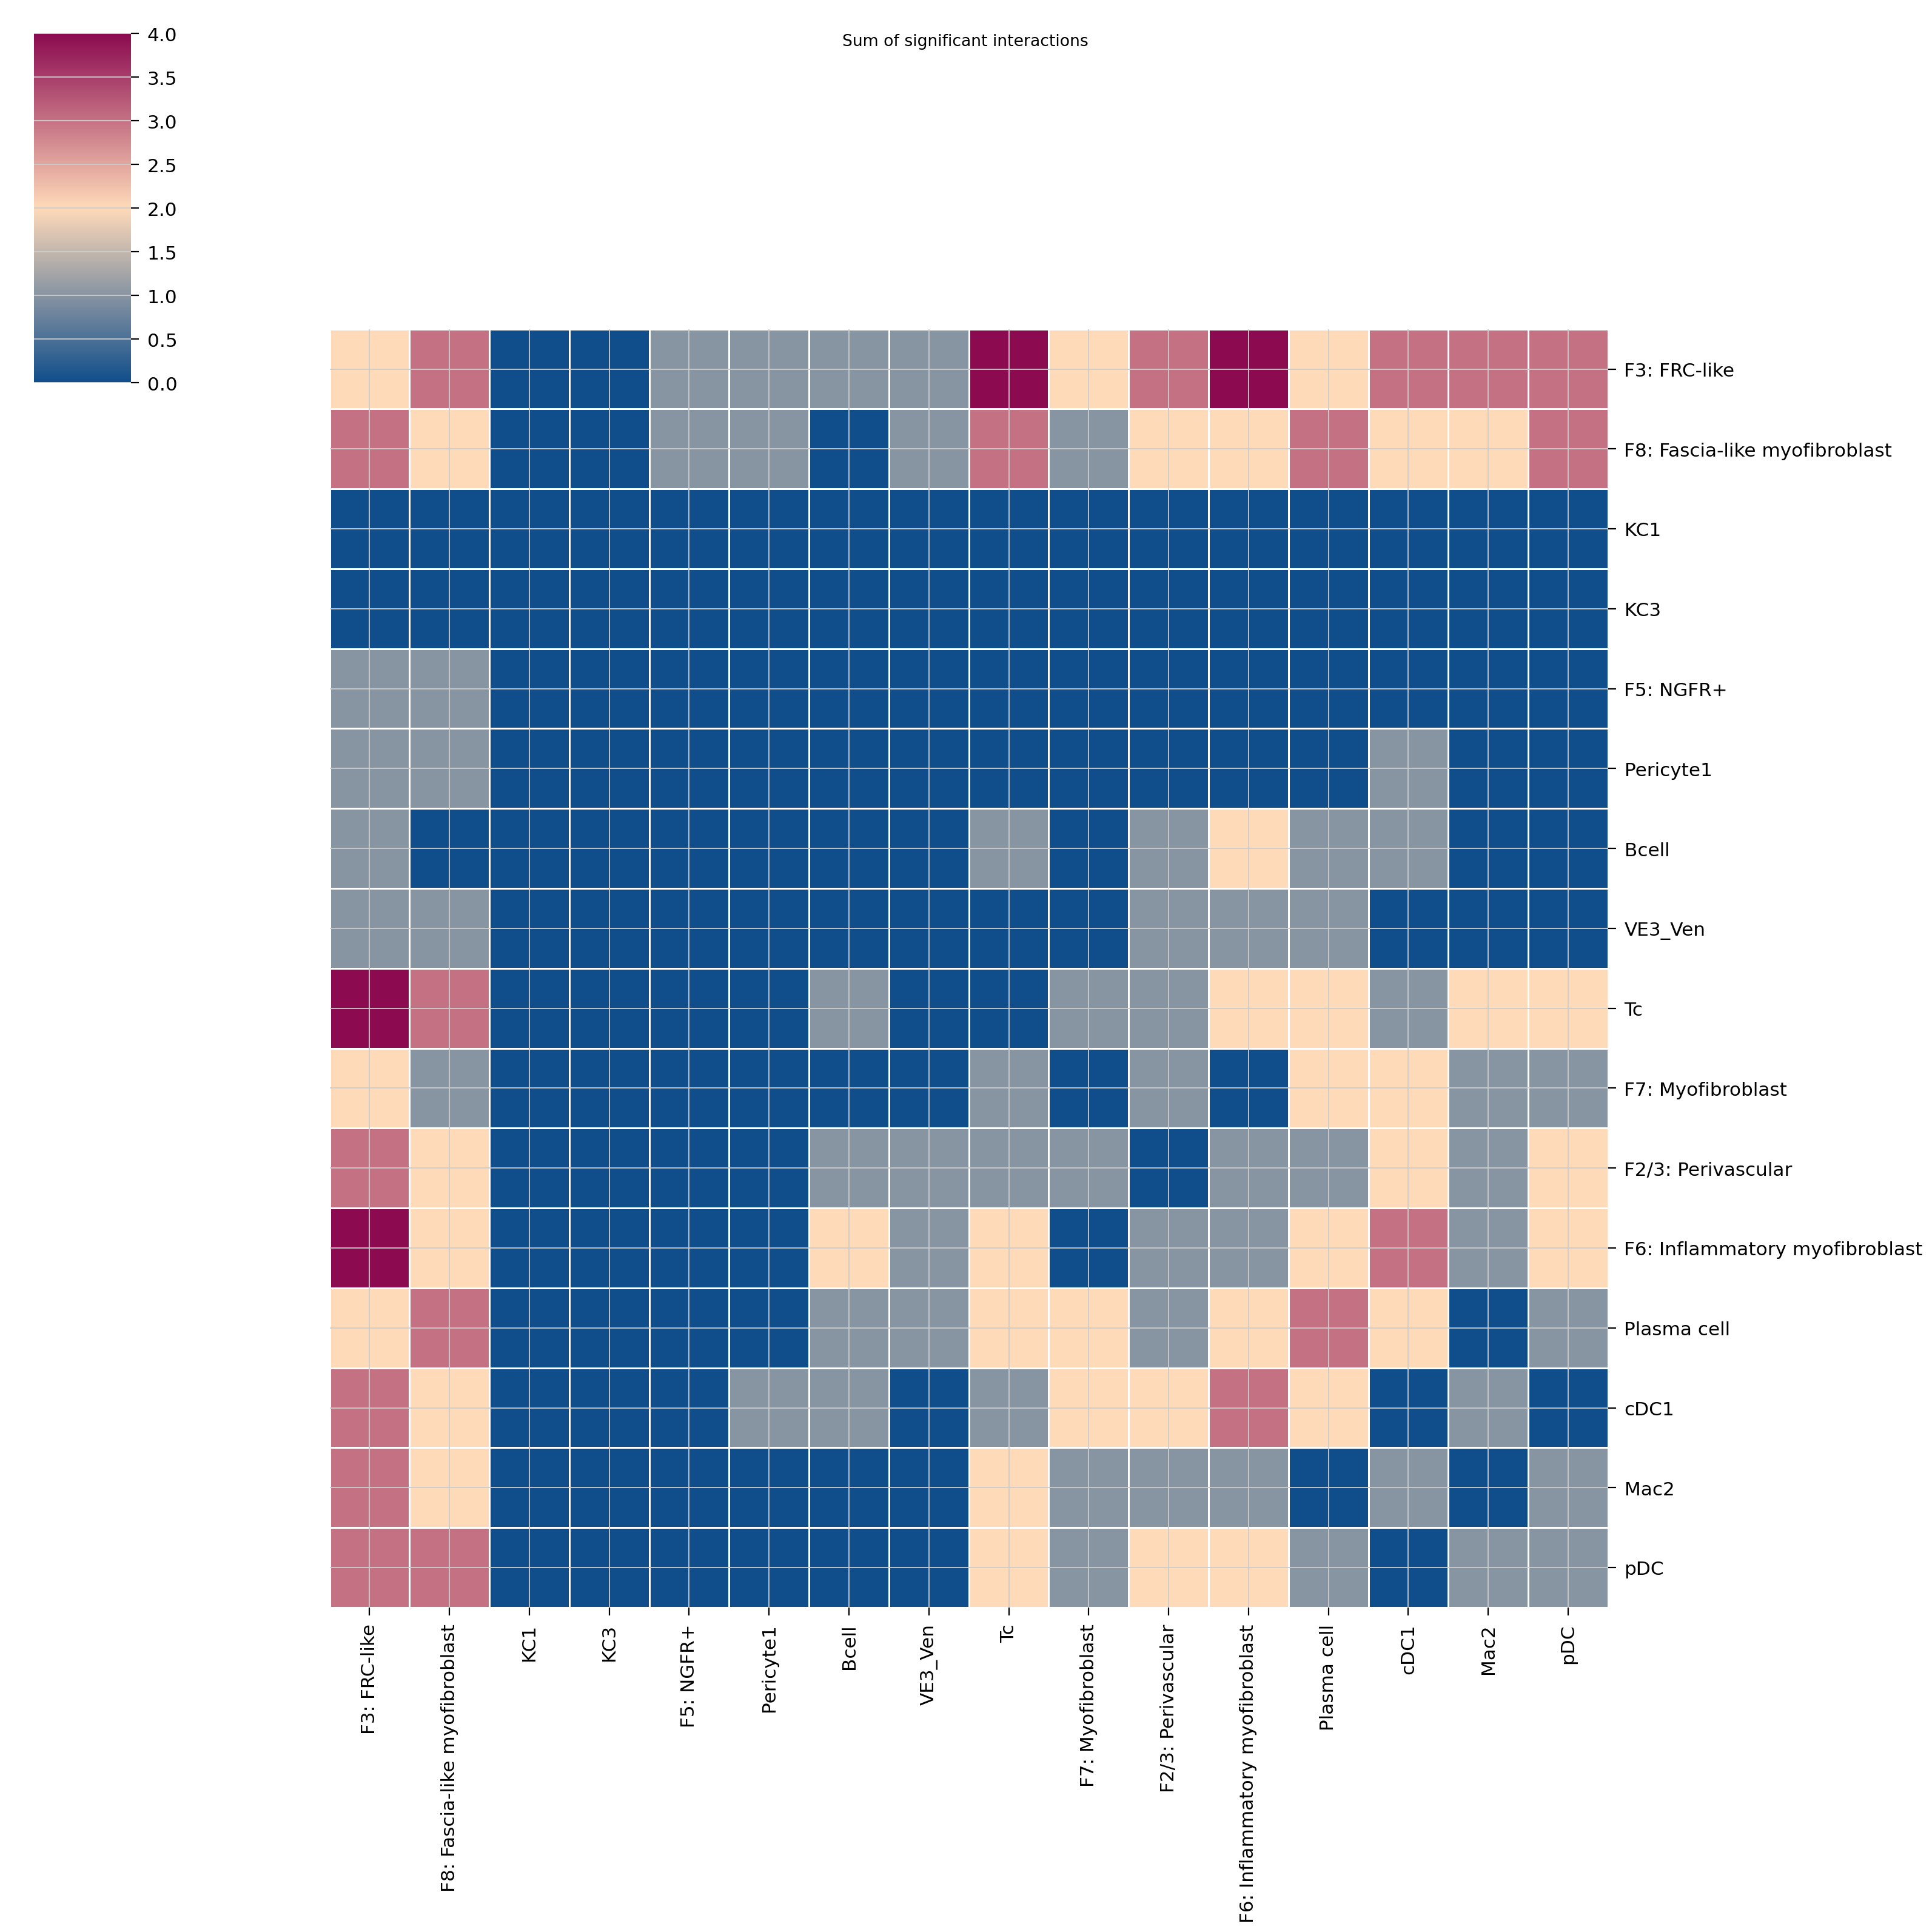

In [30]:
try:
    kpy.plot_cpdb_heatmap(pvals = pvals,
                      degs_analysis = False,
                      figsize = (20,20),
                      title = "Sum of significant interactions")
except:
    1

In [31]:
# kpy.plot_cpdb_heatmap(
#     pvals=pvals, cell_types=["MigDC", "Tnaive/Tcm",], figsize=(4, 4), title="Sum of significant interactions"
# )

In [32]:
# kpy.plot_cpdb(
#     adata = adata,
#     cell_type1 = "PV MYH11|PV STEAP4|PV MMPP11",
#     cell_type2 = "EVT_1|EVT_2|GC|iEVT|eEVT|VCT_CCC",
#     means = cpdb_results['means'],
#     pvals = cpdb_results['pvalues'],
#     celltype_key = "cell_labels",
#     genes = ["TGFB2", "CSF1R"],
#     figsize = (10, 3),
#     title = "Interactions between\nPV and trophoblast",
#     max_size = 3,
#     highlight_size = 0.75,
#     degs_analysis = False,
#     standard_scale = True,
#     interaction_scores = cpdb_results['interaction_scores'],
#     scale_alpha_by_interaction_scores = True
# )

In [33]:
adata.obs["lvl5_annotation"].unique(), 

(['Plasma cell', 'cDC1', 'KC1', 'KC3', 'pDC', ..., 'F8: Fascia-like myofibroblast', 'F6: Inflammatory myofibroblast', 'Bcell', 'F2/3: Perivascular', 'Pericyte1']
 Length: 16
 Categories (16, object): ['Bcell', 'F2/3: Perivascular', 'F3: FRC-like', 'F5: NGFR+', ..., 'Tc', 'VE3_Ven', 'cDC1', 'pDC'],)

In [34]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Plasma cell', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['Mac2'],      # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [35]:
search_results=search_results[search_results["significant_mean"]>1]
search_results.head(50)



,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [36]:
# TOP50 = ['MZB1',
#  'CYBA',
#  'XBP1',
#  'DERL3',
#  'TENT5C',
#  'CD79A',
#  'POU2AF1',
#  'PIM2',
#  'LGMN',
#  'NCF1',
#  'CD14',
#  'STAB1',
#  'CD163',
#  'IRF4',
#  'SIGLEC1',
#  'C4A',
#  'FCRL5',
#  'C4B',
#  'F13A1',
#  'CD4',
#  'MRC1',
#  'CXCR4',
#  'SLCO2B1',
#  'PDIA4',
#  'CYBB',
#  'CD38',
#  'SLAMF7',
#  'CD27',
#  'CSF1R',
#  'MSR1',
#  'LILRB5',
#  'SLC40A1',
#  'HYOU1',
#  'MARCO',
#  'CXCL12',
#  'FCGR2A',
#  'COL5A1',
#  'CTSL',
#  'RPN1',
#  'COL5A2',
#  'IKZF3',
#  'ALOX5',
#  'IRF1',
#  'CCL18',
#  'PLTP',
#  'CD209',
#  'FOLR2',
#  'ADAM12',
#  'THY1',
#  'PRDM1']

# TOP100=['MZB1',
#  'CYBA',
#  'XBP1',
#  'DERL3',
#  'TENT5C',
#  'CD79A',
#  'POU2AF1',
#  'PIM2',
#  'LGMN',
#  'NCF1',
#  'CD14',
#  'STAB1',
#  'CD163',
#  'IRF4',
#  'SIGLEC1',
#  'C4A',
#  'FCRL5',
#  'C4B',
#  'F13A1',
#  'CD4',
#  'MRC1',
#  'CXCR4',
#  'SLCO2B1',
#  'PDIA4',
#  'CYBB',
#  'CD38',
#  'SLAMF7',
#  'CD27',
#  'CSF1R',
#  'MSR1',
#  'LILRB5',
#  'SLC40A1',
#  'HYOU1',
#  'MARCO',
#  'CXCL12',
#  'FCGR2A',
#  'COL5A1',
#  'CTSL',
#  'RPN1',
#  'COL5A2',
#  'IKZF3',
#  'ALOX5',
#  'IRF1',
#  'CCL18',
#  'PLTP',
#  'CD209',
#  'FOLR2',
#  'ADAM12',
#  'THY1',
#  'PRDM1',
#  'SELPLG',
#  'ITGB2',
#  'ADAMDEC1',
#  'ITGAL',
#  'CCL13',
#  'HSPA6',
#  'VSIG4',
#  'AEBP1',
#  'GAS6',
#  'PDGFRA',
#  'ACAP1',
#  'CDH11',
#  'SPI1',
#  'MMP11',
#  'SOCS3',
#  'IL21R',
#  'UCP2',
#  'KRTCAP2',
#  'ITGAX',
#  'CTSK',
#  'HCK',
#  'CTSC',
#  'CSF2RB',
#  'PLAUR',
#  'POSTN',
#  'COL4A4',
#  'MMP14',
#  'MMP9',
#  'EGFL6',
#  'TDO2',
#  'OLFML3',
#  'LILRB1',
#  'P2RX1',
#  'HDC',
#  'LRRC15',
#  'CLEC4M',
#  'IL2RG',
#  'CTHRC1',
#  'CCN5',
#  'CFLAR',
#  'CTSG',
#  'CD99',
#  'IGF1',
#  'SND1',
#  'LRRC59',
#  'HMOX1',
#  'ANPEP',
#  'TCF4',
#  'CMA1',
#  'JAK3']
TOP50=['MZB1',
 'CD79A',
 'C1QTNF6',
 'C4B',
 'CDH11',
 'HTRA1',
 'POU2AF1',
 'CCN5',
 'EGFL6',
 'DERL3',
 'C4A',
 'AXL',
 'RNASE3',
 'CD19',
 'COL5A1',
 'COL5A2',
 'ADM',
 'NFATC4',
 'LTBP2',
 'MTCL1',
 'PDGFRL',
 'CLSTN3',
 'FAP',
 'TMEM119',
 'SPON1',
 'ASPN',
 'MAN1A1',
 'MSR1',
 'COMP',
 'THBS2',
 'ZBP1',
 'PHLDB2',
 'ABI3BP',
 'SIGLEC1',
 'ADRA2A',
 'ANGPTL2',
 'DNM1',
 'MFAP5',
 'MME',
 'ALDH1B1',
 'CD38',
 'ACKR3',
 'CD27',
 'TIE1',
 'OLFML3',
 'SULF1',
 'PIM2',
 'HMCN1',
 'JAM3',
 'NTN1',
 'CCN4',
 'AEBP1',
 'GLT8D2',
 'MYO1B',
 'HNMT',
 'LRRC15',
 'MAP1B',
 'FCGR2A',
 'PIK3R1',
 'DDX31',
 'TMEM98',
 'HOXB4',
 'AOC3',
 'SHFL',
 'NCF1',
 'IFRD1',
 'COCH',
 'LAIR1',
 'TRPM2',
 'MAPK12',
 'RAI2',
 'CYBA',
 'CTSK',
 'PMP22',
 'CTHRC1',
 'GLCCI1',
 'AFF2',
 'TWIST1',
 'FOLR2',
 'EBF1',
 'DAZL',
 'TOX',
 'GRIN2D',
 'KLK10',
 'EDNRA',
 'PM20D1',
 'FZD4',
 'PDE2A',
 'IL11',
 'ENPEP',
 'RECK',
 'MAP1A',
 'SMARCA1',
 'AKT3',
 'MRC2',
 'KDR',
 'SLIT2',
 'TBXAS1',
 'TBX2',
 'LILRB5']

In [37]:
adata.obs["fine_annotation"].unique()

['Plasma cell', 'cDC1', 'KC1', 'KC3', 'pDC', ..., 'F8: Fascia-like myofibroblast', 'F6: Inflammatory myofibroblast', 'Bcell', 'F2/3: Perivascular', 'Pericyte1']
Length: 16
Categories (16, object): ['Bcell', 'F2/3: Perivascular', 'F3: FRC-like', 'F5: NGFR+', ..., 'Tc', 'VE3_Ven', 'cDC1', 'pDC']

In [38]:
NEW_PLASMA=['DERL3',
 'NCF1',
 'MZB1',
 'GZMB',
 'IRF8',
 'CARD11',
 'GLCCI1',
 'CCR2',
 'POU2F2',
 'GUCY2D',
 'ZBP1',
 'PHEX',
 'IL3RA',
 'CYBA',
 'LILRB1',
 'C4B',
 'RUNX2',
 'PIM2',
 'RUBCNL',
 'ZFAT',
 'POU2AF1',
 'CD79A',
 'TLR7',
 'IGHE',
 'MS4A1',
 'CXCL12',
 'PLEKHH2',
 'CYBB',
 'CUX2',
 'CXCR3',
 'LAIR1',
 'IL10RA',
 'CD4',
 'COL4A4',
 'SLC7A7',
 'WDFY4',
 'KMO',
 'C4A',
 'BTK',
 'ICAM4',
 'THEMIS2',
 'CD300A',
 'IKZF3',
 'CMKLR1',
 'TRPM2',
 'NCF4',
 'IL16',
 'STAP1',
 'CD22',
 'CD38',
 'CD19',
 'ACAP1',
 'FCER2',
 'RORB',
 'CXCR4',
 'SMPD3',
 'SP140',
 'MAP1A',
 'SCIMP',
 'CD68',
 'SIRPB1',
 'TREML2',
 'STMN2',
 'CP',
 'CSF2RB',
 'ESR2',
 'CDKN2A',
 'STEAP1',
 'RASSF2',
 'PIK3CD',
 'CD180',
 'SEPTIN6',
 'CYP46A1',
 'CXCL2',
 'P2RY14',
 'CCN4',
 'TOX',
 'PPP1R16B',
 'LAIR2',
 'EVI2B',
 'IL5RA',
 'PAX1',
 'TBX19',
 'PTPN6',
 'CALCB',
 'ADAMDEC1',
 'CIITA',
 'PTHLH',
 'CPZ',
 'IL15',
 'DPT',
 'CR1',
 'SLAMF1',
 'IGSF1',
 'BVES',
 'CYSLTR1',
 'NEK6',
 'SP9',
 'ESR1',
 'ANKRD6']

In [39]:
IMMUNE =adata.obs["fine_annotation"].unique() #['Pericyte1', 'F1: Superficial', 'F2: Universal', 'Mast cell', 'Tc', 'Mac2', 'F3: FRC-like', 'F2/3: Stroma_PPARG+', 'F4: DS_DPEP1+']
IMMUNE =  "|".join(IMMUNE)
IMMUNE

'Plasma cell|cDC1|KC1|KC3|pDC|VE3_Ven|F7: Myofibroblast|F5: NGFR+|Tc|F3: FRC-like|Mac2|F8: Fascia-like myofibroblast|F6: Inflammatory myofibroblast|Bcell|F2/3: Perivascular|Pericyte1'

In [43]:
IMMUNE='cDC1|KC1|KC3|pDC|VE3_Ven|F7: Myofibroblast|F5: NGFR+|Tc|F3: FRC-like|Mac2|F8: Fascia-like myofibroblast|F6: Inflammatory myofibroblast|Bcell|F2/3: Perivascular|Pericyte1'

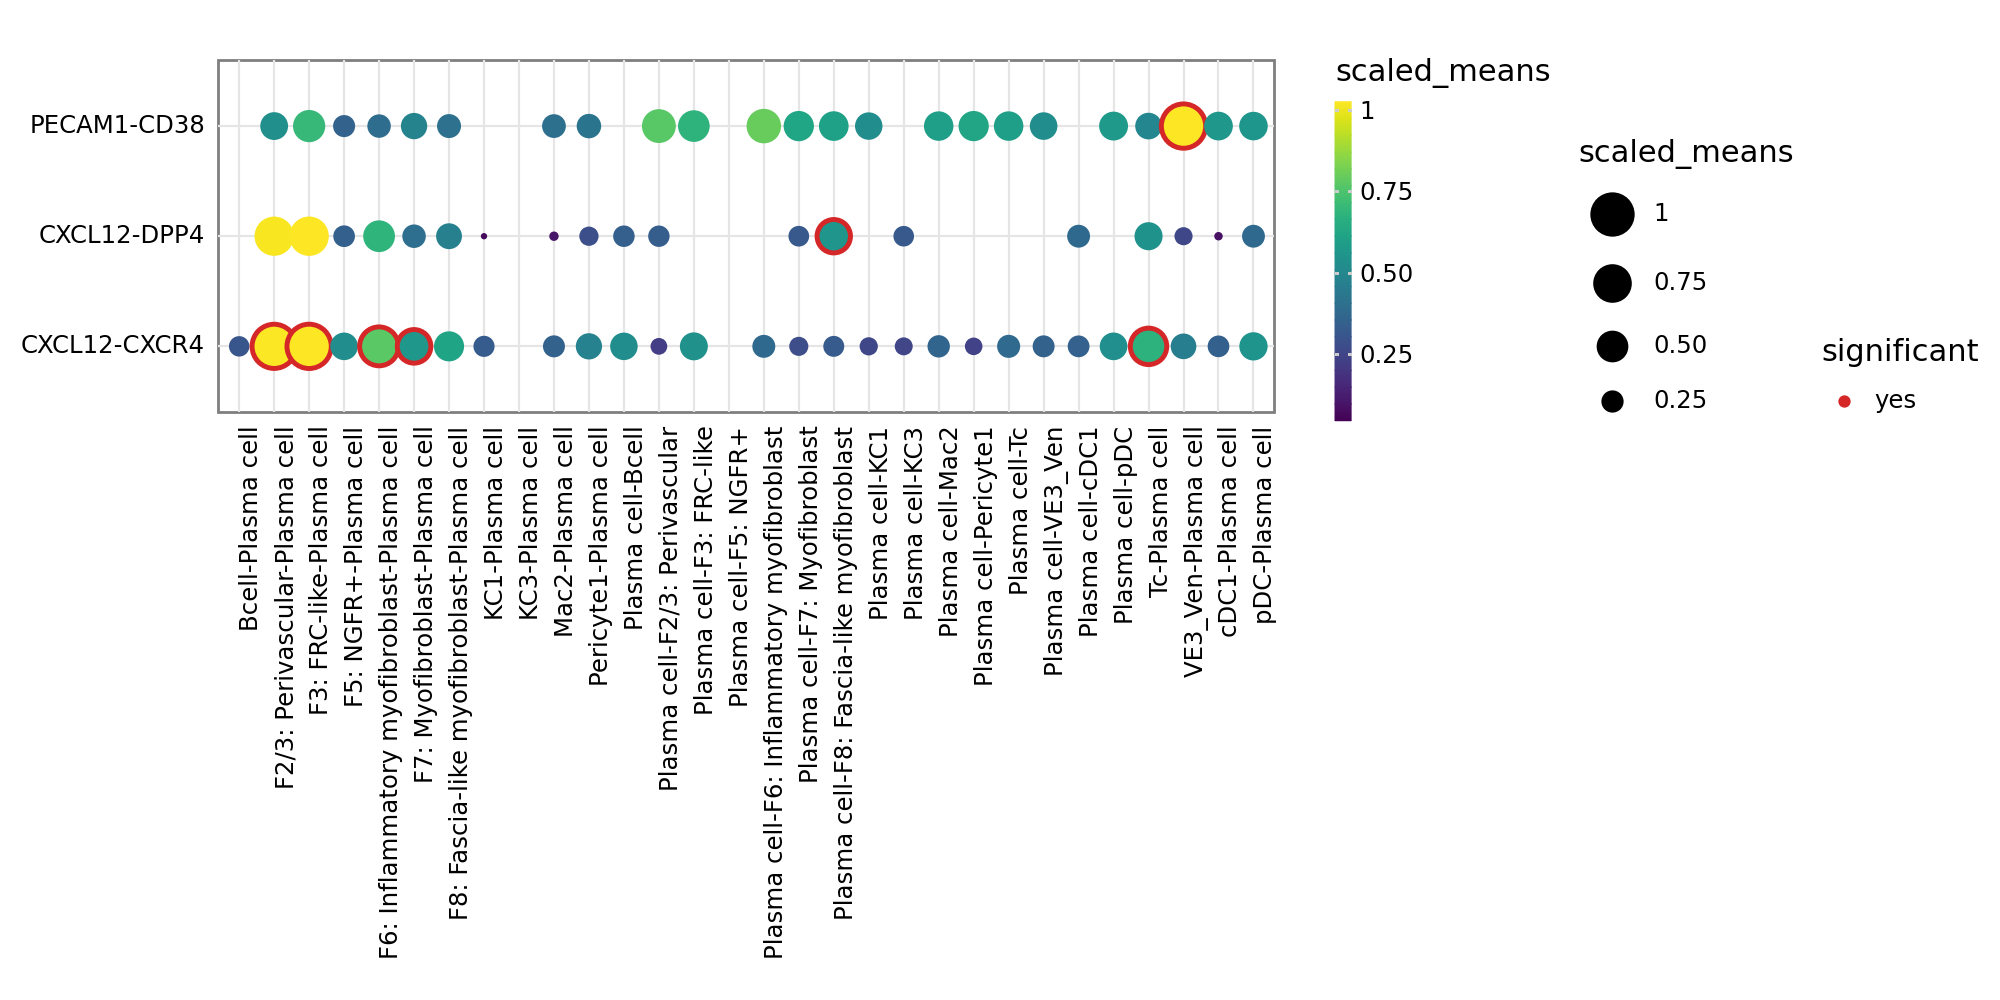

<Figure Size: (1000 x 500)>

In [46]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Plasma cell",
    cell_type2= IMMUNE,
     genes = NEW_PLASMA,
    means=means,
    pvals=pvals,
    celltype_key="fine_annotation",
    highlight_size=1,
    figsize=(10, 5),
)



In [41]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Plasma cell",
    cell_type2= IMMUNE,
     genes = TOP100,
    means=means,
    pvals=pvals,
    celltype_key="fine_annotation",
    highlight_size=1,
    figsize=(10, 5),
)



NameError: name 'TOP100' is not defined

In [ ]:
genes2=['PECAM1',
 'EPAS1',
 'EGFL7',
 'SHANK3',
 'PLVAP',
 'HSPG2',
 'BCAM',
 'COL4A1',
 'SOX18',
 'ENG',
 'TIE1',
 'COL4A2',
 'MMRN2',
 'CD34',
 'CLDN5',
 'MYH9',
 'KDR',
 'NOS3',
 'MCAM',
 'COL18A1',
 'PODXL',
 'ROBO4',
 'PDE2A',
 'NOTCH4',
 'CDH5',
 'TGFBR2',
 'TFPI',
 'RAPGEF3',
 'HOXD9',
 'AOC3',
 'CCL14',
 'SPTBN1',
 'ICAM2',
 'TCF4',
 'GIMAP5',
 'ACE',
 'APLNR',
 'MSN',
 'TSPAN7',
 'TINAGL1',
 'SLC9A3R2',
 'CLEC14A',
 'ITGA5',
 'FZD4',
 'RGS5',
 'SELP',
 'NRN1',
 'FLT4',
 'TMEM173',
 'SYNPO2',
 'MYLK',
 'SCN4B',
 'ADGRA2',
 'NPR1',
 'NOSTRIN',
 'SOX17',
 'ENPEP',
 'ITGA6',
 'TBX2',
 'ADAMTS1',
 'NES',
 'SEMA4C',
 'SCARB1',
 'ENPP2',
 'HEY1',
 'TNFRSF1B',
 'LRRC32',
 'CDC37',
 'GATA2',
 'LBH',
 'DUSP23',
 'BCR',
 'KCNJ8',
 'SELE',
 'NOTCH3',
 'MAPK3',
 'PARM1',
 'SLC2A3',
 'ACACB',
 'RFTN1',
 'LOXL2',
 'FLNC',
 'IGFBP2',
 'CSF2RB',
 'ADRA2A',
 'CTSH',
 'LDB3',
 'STAB1',
 'DACH1',
 'CACNA1H',
 'JAK3',
 'PGF',
 'STEAP4',
 'CCN2',
 'SOCS3',
 'SMTN',
 'MX1',
 'THBS1',
 'INHBB',
 'ITGB4']

kpy.plot_cpdb(
    adata=adata,
    cell_type1="Plasma cell",
    cell_type2= IMMUNE,
     genes = genes2,
    means=means,
    pvals=pvals,
    celltype_key="fine_annotation",
    highlight_size=1,
    figsize=(10, 5),
)



In [ ]:
genes = ["CXCL12", "CXCR4", "PECAM1", "CD38", "AXL","GAS6"]

sc.pl.DotPlot(
    adata,
   genes,
    #swap_axes=True,
    groupby="lvl5_annotation",
   vmax=3,
    #    colorbar_title='Mean expression\n(variance scaled)', 
   # standard_scale="var",
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True, #vmax=.8
               dot_max=1
          )\
.show()

 

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Plasma cell",
    cell_type2= "Mac2",
     genes = GENES,
    means=means,
    pvals=pvals,
    celltype_key="fine_annotation",
    highlight_size=1,
    figsize=(10, 5),
)



In [ ]:
end

In [ ]:
# -----------------------------------------------------------
#  You already have `search_results` from search_utils.   
#  These are the only columns it contains:
#  ['interacting_pair', 'partner_a', 'partner_b', 'gene_a',
#   'gene_b', 'directionality', 'classification',
#   'interacting_cells', 'significant_mean']
#
#  There is **no p-value column** and no separate score column,
#  so the only quantitative handle on “how important” an
#  interaction is right now is `significant_mean`.
#  Larger → stronger / more biologically punchy.
# -----------------------------------------------------------

import pandas as pd

# --- sanity check -----------------------------------------------------------
expected = {
    'interacting_pair', 'partner_a', 'partner_b',
    'gene_a', 'gene_b', 'directionality',
    'classification', 'interacting_cells', 'significant_mean'
}
missing = expected.difference(search_results.columns)
if missing:
    raise ValueError(f"DataFrame is missing columns: {missing}")

# --- rank by significance ---------------------------------------------------
# If you later add a p-value column just sort on that first
# with ascending=True, then significant_mean descending.
sorted_hits = (search_results
               .sort_values('significant_mean', ascending=False)
               .reset_index(drop=True))

# --- inspect / save ---------------------------------------------------------
sorted_hits.head(50)   #  #     # whatever slice you need
#top50.to_string(index=False)  # full table in console

#  Optional: dump to CSV for the lab Slack channel
# top50.to_csv('TRM_vs_KC_top50_interactions.csv', index=False)

In [ ]:
# --- The search you already ran --------------------------------------------
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['ILC1'],
    query_cell_types_2 = adata.obs["lvl5_annotation"].unique(),
    significant_means   = means,
    deconvoluted        = pvals,
    interaction_scores  = interaction_scores,
    query_minimum_score = 50,
    separator           = '|',
    long_format         = True,     # keep the wide-format junk out
)

# --- Ranking the hits -------------------------------------------------------
# 1.  CellPhoneDB writes the interaction score to the `interaction_score` column.
# 2.  P-values live in `pvalue` (lower = more significant).
# 3.  Means are in `mean` or `mean_xx` depending on your version.

# Sort   (a) ascending p-value, then (b) descending interaction score
# sorted_hits = (search_results
#                .sort_values(['pvalue', 'interaction_score'],
#                             ascending=[True, False])
#                .reset_index(drop=True))

# # Grab whatever slice you need
# top20 = sorted_hits.head(20)

# print(top20.to_string(index=False))

In [ ]:
# search_results["gene_a"].unique()


In [ ]:
# search_results["gene_b"].unique()


In [ ]:
genes = ['CXCR4', 'PTPRC', 'CLEC2D', 'MRC1', 'KLRC1', 'KLRC2', 'KLRK1',
       'TYROBP', 'BSG', 'KLRF1', 'XCR1', 'TGFBR3', 'EGFR', 'VSIR',
       'PTGER4', 'PILRA', 'ADGRE5', 'CXCL14', 'SEMA4D', 'KLRB1', 'PTPRC', 'HLA-E', 'CD44', 'PPIA',
       'CLEC2B', 'XCL1', 'XCL2', 'TGFB1', 'AREG', 'CD99', 'CD55',
       'PLAUR']

sc.pl.DotPlot(
    adata,
   genes,
    #swap_axes=True,
    groupby="lvl5_annotation",
   vmax=3,
    #    colorbar_title='Mean expression\n(variance scaled)', 
   # standard_scale="var",
) \
    .style(cmap='Reds', color_on='square', dot_edge_color='black', dot_edge_lw=1, grid=True, #vmax=.8
               dot_max=1
          )\
.show()

 

In [ ]:
search_results["interacting_pair"].unique()


In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1=
    cell_type2=  'KC_Sebocyte_DuctOuter','TRM_IL13+', 
    # genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 10),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1='TRM_IL13+',
    cell_type2=  'KC_Sebocyte_DuctOuter',
    # genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['TRM_IL13+', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 =  ['KC_Sebo'],    # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
# try:
#     decon=cpdb_results['deconvoluted']
#     deconv=cpdb_results['deconvoluted']
#     means = cpdb_results['means']
#     pvals = cpdb_results['pvalues']
#     interaction_scores=cpdb_results['interaction_scores']
#     print("instantantiated")
# except:
#     print("not loaded")
    
#     deconv = pd.read_csv("/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_10_09_2024_201259.txt",  sep="\t")
#     means = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_10_09_2024_201259.txt', sep="\t")
#     #means = 
#     pvals = pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_10_09_2024_201259.txt", sep="\t")
#     interaction_scores=pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_10_09_2024_201259.txt", sep="\t")
#     import anndata
#     counts_file_path = '/nfs/team298/ls34/cellphonedb/input_files/normalised_log_counts_psoriasis.h5ad'
#     adata = anndata.read_h5ad(counts_file_path)
#     adata.shape
    
#  # statistical_analysis_deconvoluted_percents_10_09_2024_201259.txt
# #5.2M -rw-r--r-- 1 ls34 team298  21M Oct  9 20:13 
# #1.8M -rw-r--r-- 1 ls34 team298  19M Oct  9 20:13 
# #768K -rw-r--r-- 1 ls34 team298 5.2M Oct  9 20:13 statistical_analysis_significant_means_10_09_2024_201259.txt
 

In [ ]:
deconv=cpdb_results['deconvoluted']

In [ ]:
list(adata.obs["lvl5_annotation"].unique())

In [ ]:
IMMUNE =  ['cDC2: MMP12hi',
 'Th',
 #'KC_Sebocyte_DuctOuter',
 'MigDC (cDC2)',
 'cDC2: EREG+CCR7+',
 'TRM_IL13+',
 'cDC1',
 'ILC1',
 'cDC2',
 #'KC_Sebocyte_DuctInner',
 #'KC1-2_cycling',
 #'ASIC2+_Mechanoreceptor',
 #'MoDC',
 'T_Prolif',
 'Treg',
 #'KC_Sebocyte_DuctInner_Junction',
 'TRM_IL17+',
 'ILC1_NCR2+P2RX7+']
        

In [ ]:
IMMUNE =  "|".join(IMMUNE)
IMMUNE

In [ ]:
,'KC_Sebocyte_DuctInner', 'KC_Sebocyte_DuctInner_Junction', 

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= [ 'KC_Sebocyte_DuctOuter'],
    cell_type2= IMMUNE,
     #genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 8),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= [ 'KC_Sebocyte_DuctOuter'],
    cell_type2= IMMUNE,
    genes=["CFB", "CCL1", "SFXN1", "EGR2", "SOCS1", "IL2RG", "CXCL16", "SLCO2B1", "CCL17", "ZAP70", "BATF", "IKZF1", "HCK", "TNFRSF12A", "PNP", "SPI1", "PIK3CD", "PDPN", "XDH", "CCL22", 
     "FAS", "TNFRSF10A",  "CD6" , "CA9", "RELT", "LAT", "PTAFR", "TCF7", "CXCL10", "CRB2", "BCAN", "NTRK1", "CXCL9", "CGAS", "CD1A"],
     #genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(10, 8),
)




In [ ]:
from cellphonedb.utils import search_utils
 
search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F6: Inflammatory myofibroblast', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = IMMUNE,     # List of cells 2, will be paired to cells 1 (list or 'All').
    #   query_genes = ["CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3",
    # "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",
    # "STAT4", "CCL11",],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
FB = [x for x in  adata.obs["lvl5_annotation"].unique() if x.startswith("F")]

FB =  "|".join(FB)
FB

In [ ]:
FB

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['pDC', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(60)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="pDC",
    cell_type2= IMMUNE,
     #genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 8),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= IMMUNE,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=5,
    figsize=(20, 8),
)



In [ ]:
cell_types = [
   # "Mac1",
    "Mac2_CCL14hi", "MoDC", "Mono", "Neutrophil", "cDC1", "cDC2: IL1B+"
]

SHORT = "|".join(cell_types)


In [ ]:

kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= SHORT,
     #genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(14, 8),
)



In [ ]:
STOP

In [ ]:

kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= SHORT,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=2,
    figsize=(14, 8),
)



In [ ]:

kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= SHORT,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=2,
    figsize=(10, 6),
    save="fig5f.pdf"
)



In [ ]:
stop

In [ ]:

kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= SHORT,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=5,
    figsize=(14, 8),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= IMMUNE,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 8),
    savefig="f6_ccc.png"
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= IMMUNE,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 8),
    save="f6_ccc.pdf"
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= IMMUNE,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3",
    "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",
    "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(10, 10),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2="Neutrophil",
      # query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
       #    "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2=["Neutrophil"|"Monocyte"]
      # query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
       #    "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F3: CCL19+', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "Mac1", "Mac2", "MigDC", "LC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
decon=cpdb_results['deconvoluted']
deconv=cpdb_results['deconvoluted']
means = cpdb_results['means']
pvals = cpdb_results['pvalues']
interaction_scores=cpdb_results['interaction_scores']
print("instantantiated")

In [ ]:
# kpy.plot_cpdb(
#     adata=adata,
#     cell_type1="F*_perikeloid",
#     cell_type2=".",
#     means=means,
#     pvals=pvals,
#     celltype_key="lvl5_annotation",
#     highlight_size=1,
#     figsize=(20, 20),
#     scale_alpha_by_interaction_scores=True,
#     min_interaction_score=60,
# )



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = [  ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 =  ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "Tnaive/Tcm|"],      # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,        # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,      # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(100)

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = [ "MigDC" ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "Tnaive/Tcm|"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,        # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,      # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F3: CCL19+', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "MigDC", "Plasma cell"],     # List of cells 2, will be paired to cells 1 (list or 'All').
    query_genes = ['TNFSF13B'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ["Pericyte1_CCL19+_signalling", "VE1_ADAMTS6hi", "VE3_SELPhi",  ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "ILC2", "ILC2_inflammatory", "Th", "Tc_IL13"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['MigDC', "Mac1", "Mac2" ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "ILC2", "ILC2_inflammatory", "Th", "Tc_IL13"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F3: CCL19+',  ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "ILC2", "ILC2_inflammatory"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = adata.obs["lvl5_annotation"].unique(),  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "MigDC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
   query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
           "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 0,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2=adata.obs["lvl5_annotation"].unique(),
       query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
           "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)


# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 = adata.obs["lvl5_annotation"].unique(),  # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = [ "MigDC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#                                        # filter interactions based on the genes participating (list).
#  #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
#     significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
#     deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
#     query_minimum_score = 0,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# search_results.head(50)



In [ ]:
search_results.head(50)


In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Treg', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "MigDC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
list(search_results["gene_a"])

In [ ]:
list(search_results["gene_b"])

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = [ "MigDC", "cDC2: MMP12+"],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['ILC2', 'ILC2_inflammatory'],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
list(search_results["gene_a"])

In [ ]:
list(search_results["gene_b"])

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F3: CCL19+', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "MigDC", "ILC1_3", "NK_ILC1"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
search_results.tail(20)

In [ ]:
# cpdb_results.columns

In [ ]:
adata.obs["lvl3_annotation"].value_counts()

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="Tc_IL13",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
7

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg_LRRC32",
    cell_type2="MigDC",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="MigDC",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)



In [ ]:
5

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="Treg_LRRC32",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="F3: FRC-like",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    min_interaction_score=50,

)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="Tnaive/Tcm",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="LC",
    cell_type2="ILC2",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)


In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="LC",
    cell_type2="F3: CCL19+",
    means=means,
    pvals=pvals,
    celltype_key="lvl3_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Tc_IL17",
    cell_type2="F3: CCL19+",
    means=means,
    pvals=pvals,
    celltype_key="lvl3_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="VE3_SELPhi",
    cell_type2="ILC1_3",
    means=means,
    pvals=pvals,
    celltype_key="lvl3_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="VE3_SELPhi",
    cell_type2="ILC2",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="ILC1_3",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="Tc_IL13",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="ILC1_3",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="Tc",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="ILC2",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
# kpy.plot_cpdb(
#     adata=adata,
#     cell_type1="MigDC",
#     cell_type2="G",
#     means=means,
#     pvals=pvals,
#     celltype_key="lvl3_annotation",
#     highlight_size=1,
#     figsize=(20, 20),
#         scale_alpha_by_interaction_scores=True,
#     min_interaction_score=20,
# )

In [ ]:
"TNFSF4", "TNFRSF4", 
"ADGRE5", "ITGAV" "ITGB1", "CD55", "LPAR2", "LPAR3",
"ITGA4", "ITGB1", "FN1", ""
"TNFSF14", "TNFRSF14", "TNFRSF6B",
"TNFSF12", "TNFRSF25"
"TNFSF10", "TNFRSF10A","TNFRSF10B","TNFRSF10D",
"SEMA4D","PTPRC",  "PLXNB2",
"SELPLG", "SELL", "PODXL",
"PTGES", ,"PTGES2", "PTGES3",  "PTGER4", "PTGER3", 
"PTGDS", "AKR1C3","PTGDR2","PTGDR3"
"LTC4S", "CYSLTR1", 
"AKR1B1", "PTGFR", 
"NECTIN2", "TIGIT", "CD226", "PVR", "CD96", 
"ALOX5", "LTC4S", "CTSLTR1", 
"LTB", "LTBR", "ICAM3", "ICAM2", "SIRPA", "SIRPG", "CD47", "ICAM1", "ITGAL","ITGB2",
"APP", "CD74", "CD44", "TYROBP",
"CCL5","CCL22", "CCL17", "CCR4","ACKR5", "DPP4",
"BAG6", "NCR3", 
"ALDH1A1", "RORB", "TGFB1", "TGFB2", "TGFBR3", "TNFSF12", "TNGRSF12A",   "TNFSF11", "TNGRSF11A", 
"NOTCH1", "DLL1", "DLL3", "JAG1", "NOTCH2", "CD46","CNTN1",
"CXCL2", "DPP4",
"RAMP3", "ADM",
"RAMP1", "CALCA",
"PLAUR", "PLAU", "ITGB1", "ITGA4", 

"VEGFB", "FLT1",
"CRLF2", "TSLP", "TSLPR",
"CXCL16", "CXCR6",
"CD58", "CD2", 
"KLRB2", "CLEC2D", 
"ENPTD1", "ADORA2A", "NT5E", "SLC19A1",
"AREG", "EGFR", 
"CD248", "IL6R", 
"COL3A1", "ADGRG1",
"IL34", "CSF1", "CSFR1", 
"CD320", "JAML",
"IGFBP3", "TMEM219",
"APP", "CD74", "SORL1",
"CD40LG", "ITGB1", "ITGA5",
"ICOS", "ICOSLG",
"WNT5B", "SFRP2", "SFRP1", "FRZB"
"GAS6", "AXL",
"CD1B", "IL6ST",
"CD200", "CD200R1", ""

In [ ]:
STOP

In [ ]:
kpy.plot_cpdb(
    adata = adata,
    cell_type1 =['F3: CCL19+', ],  
    cell_type2 =  [ "MigDC"],  
    genes = ["CCL19"],

    means = cpdb_results['means'],
    pvals = cpdb_results['pvalues'],
    celltype_key = "lvl3_annotation",
    figsize = (10, 3),
    title = " ",
    max_size = 3,
    highlight_size = 0.75,
    degs_analysis = False,
    standard_scale = True,
    interaction_scores = cpdb_results['interaction_scores'],
    scale_alpha_by_interaction_scores = True
)

# plots

In [ ]:
import ktplotspy as kpy


In [ ]:
relevant_interactions =  cpdb_results['pvalues']

In [ ]:
kpy.plot_cpdb_heatmap(pvals=relevant_interactions, degs_analysis=False, figsize=(15, 15), title="Sum of significant interactions")


In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F3: CCL19+",
    cell_type2="MigDC",
    means=means,
    pvals=relevant_interactions,
    celltype_key="cell_labels",
    figsize=(7, 4),
    title="Interactions between\nPV and trophoblast with\ndownstream significance",
    max_size=6,
    highlight_size=0.75,
    degs_analysis=False,
    standard_scale=True,
   # cellsign=cellsign,
   # filter_by_cellsign=True,
)

In [ ]:
kpy.plot_cpdb_chord(
    adata=adata,
    cell_type1="F3: CCL19+",
    cell_type2="MigDC",
    means=means,
    pvals=pvals,
    deconvoluted=decon,
    celltype_key="lvl3_annotation",
    genes=["CCL19", "CCR7", "IL33"],
    figsize=(6, 6),
    labelposition=50,
)

In [ ]:
search_results.head(50)

In [ ]:
kpy.plot_cpdb_chord(
    adata=adata,
    cell_type1="F3: CCL19+",# "Pericyte1_CCL19+_signalling", "VE1_ADAMTS6hi", "VE3_SELPhi",],
    cell_type2= "ILC2",
    means=means,
    pvals=pvals,
    deconvoluted=deconv,
    celltype_key="lvl2_annotation",
    genes=["CCL19", "CCR7", "IL33",  'CD44', 'TYROBP', 'CXCL12', 'CXCR4', 'PTGDR2', "IL7", "IL7R", "CYSTLR2", "SELE" , "SELPLG", "CD200", "CD200R1"  ],
    figsize=(6, 6),
    labelposition=50,
)